In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('placementdata.csv')

In [3]:
print(df.shape)
df.head()

(10000, 12)


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [4]:
print(df.columns)

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='object')


In [5]:
df =df[['CGPA', 'Internships','Projects','PlacementStatus']]

In [6]:
df.head()

,CGPA,Internships,Projects,PlacementStatus
0,7.5,1,1,NotPlaced
1,8.9,0,3,Placed
2,7.3,1,2,NotPlaced
3,7.5,1,1,Placed
4,8.3,1,2,Placed


<Axes: xlabel='CGPA', ylabel='Internships'>

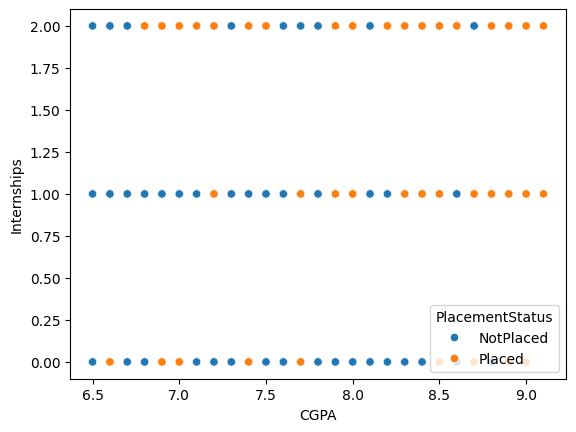

In [7]:
sns.scatterplot(data = df,x = 'CGPA', y = 'Internships', hue = 'PlacementStatus')

<Axes: xlabel='CGPA', ylabel='Projects'>

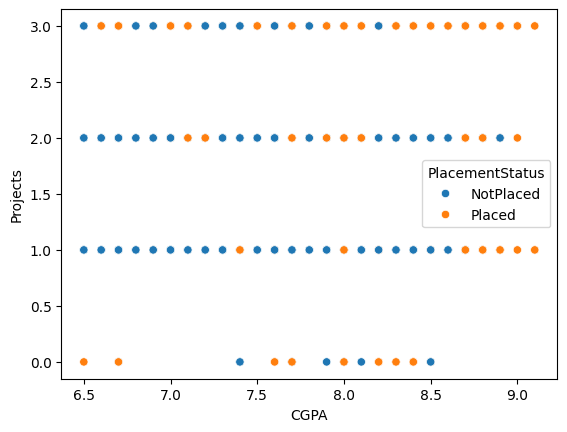

In [8]:
sns.scatterplot(data =df, x= 'CGPA', y= 'Projects', hue = 'PlacementStatus')

In [9]:
x = df.iloc[:, [0,1,2]]
y = df.iloc[:,3]

In [10]:
from sklearn.linear_model import Perceptron
p = Perceptron()

In [19]:
y = y.map({'NotPlaced' : 0, 'Placed' : 1})

In [18]:
print(y.unique())


['NotPlaced' 'Placed']


In [20]:
p.fit(x,y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [21]:
p.coef_

array([[16.9, -1. , 28. ]])

In [22]:
p.intercept_

array([-233.])

In [23]:
from mlxtend.plotting import plot_decision_regions

C:\Users\omkad\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

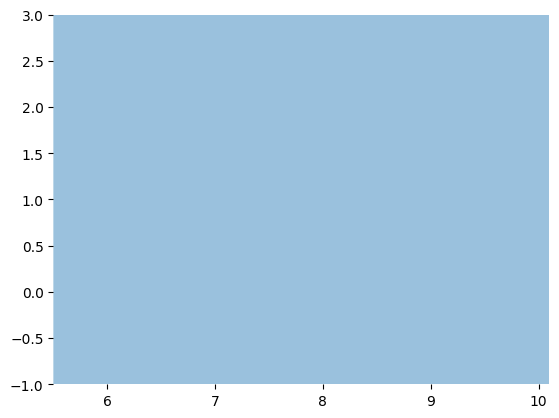

In [25]:
plot_decision_regions(x.values, y.values,feature_index=[0, 1], filler_feature_values={2: x['Projects'].mean()}, clf =p, legend = 3)